In [104]:
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
from matplotlib import markers
import pandas as pd
import numpy as np
import os

# Ahora importa el módulo
from RRAM.Representate import config_ax_IV, setup_paper_plt
    
setup_paper_plt(plt, latex=True, scaling=3)

In [80]:
def split_dataframe_at_max(df):
    # Encontrar el índice del valor máximo de voltaje
    max_index = df["voltage"].idxmax()

    # Dividir el DataFrame
    df_ascendente = df.iloc[: max_index + 1]  # Hasta el máximo (inclusive)
    df_descendente = df.iloc[max_index+1:]  # Desde el máximo hasta el final

    return df_ascendente, df_descendente

In [81]:
def leer_datos_exp(num_curva: int):
    ruta_set = (os.getcwd()+ f"/Datos_Experimentales/Medidas_Experimentales_RRAM/Cycle_p_{num_curva}.txt")
    
    # Definir estructura de datos común
    dtype = [("voltage", "f8"), ("current", "f8"), ("time", "f8")]

    # Leer archivos con numpy
    datos_set = np.genfromtxt(ruta_set, dtype=dtype, encoding="utf-8")

    # Convertir a DataFrames
    df_set = pd.DataFrame(datos_set)
    
    df_pp_set, df_sp_set = split_dataframe_at_max(df_set)

    return df_pp_set, df_sp_set

In [82]:
def leer_datos_sim(num_simulacion: int):
    """
    Lee los datos de simulación de archivos CSV y los organiza en DataFrames.
    Esta función toma un número de simulación como entrada, construye las rutas
    de los archivos correspondientes a los datos de "set" y "reset", y lee los
    datos de estos archivos en formato CSV. Los datos se convierten en DataFrames
    con columnas reordenadas.
    Args:
        num_simulacion (int): Número de la simulación para identificar las rutas
                              de los archivos de datos.
    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Una tupla que contiene dos DataFrames:
            - df_set: DataFrame con los datos de "set" (columnas: "voltage", "current", "time").
            - df_reset: DataFrame con los datos de "reset" (columnas: "voltage", "current", "time").
    Notas:
        - Los archivos CSV deben estar ubicados en las rutas esperadas dentro del
          directorio de trabajo actual.
        - Solo se leen las primeras tres columnas de los archivos CSV.
        - Los nombres de las columnas esperadas son "time", "voltage" y "current".
        - Se omite la primera fila de los archivos CSV al leer los datos.
    """
    
    ruta_pp_set = (
        os.getcwd()
        + f"/Results/simulation_{num_simulacion}/set/resultados_pp_set_{num_simulacion}.csv"
    )
    ruta_sp_set = (
        os.getcwd()
        + f"/Results/simulation_{num_simulacion}/set/resultados_sp_set_{num_simulacion}.csv"
    )
    
    # Leer solo las primeras 3 columnas
    usecols = (0, 1, 2)  # Índices de las columnas que queremos leer

    # Definir tipos de datos para cada columna
    dtypes = {"time": "float64", "voltage": "float64", "current": "float64"}
    
    # Leer archivos con numpy
    datos_pp_set = pd.read_csv(
        ruta_pp_set,
        encoding="utf-8",
        usecols=usecols,
        names=["time", "voltage", "current"],
        dtype=dtypes,
        skiprows=1,
    )
    datos_sp_set = pd.read_csv(
        ruta_sp_set,
        encoding="utf-8",
        usecols=usecols,
        names=["time", "voltage", "current"],
        dtype=dtypes,
        skiprows=1,
    )

    # Convertir a DataFrames
    df_pp_set = pd.DataFrame(datos_pp_set)
    df_sp_set = pd.DataFrame(datos_sp_set)
    
    df_pp_set = df_pp_set.reindex(columns=["voltage", "current", "time"])
    df_sp_set = df_sp_set.reindex(columns=["voltage", "current", "time"])

    return df_pp_set, df_sp_set

In [83]:
def comparar_intensidades(df_exp, df_sim):
    """
    Compara intensidades experimentales con simuladas buscando para cada voltaje experimental
    el voltaje simulado más cercano y calculando la diferencia y valor absoluto entre intensidades.

    Parámetros:
    - df_exp: DataFrame experimental con columnas ['voltaje', 'intensidad', 'tiempo']
    - df_sim: DataFrame simulado con columnas ['voltaje', 'intensidad', 'tiempo']

    Retorna:
    - DataFrame con columnas ['voltaje_exp', 'intensidad_exp', 'voltaje_sim_cercano', 'intensidad_sim', 'diferencia', 'abs_diferencia']
    """
    voltajes_sim = df_sim["voltage"].values
    intensidades_sim = df_sim["current"].values

    resultados = []

    for _, row_exp in df_exp.iterrows():
        v_exp = row_exp["voltage"]
        i_exp = row_exp["current"]

        # índice del voltaje simulado más cercano
        idx_min = np.argmin(np.abs(voltajes_sim - v_exp))
        v_sim_cercano = voltajes_sim[idx_min]
        i_sim_cercano = intensidades_sim[idx_min]

        diff = i_exp - i_sim_cercano
        abs_diff = abs(diff)

        resultados.append(
            {
                "voltaje_exp": v_exp,
                "intensidad_exp": i_exp,
                "voltaje_sim_cercano": v_sim_cercano,
                "intensidad_sim": i_sim_cercano,
                "diferencia": diff,
                "abs_diferencia": abs_diff,
            }
        )

    return pd.DataFrame(resultados)

In [ ]:
errores_totales = []

# Datos de la curva simulada que mantengo fija, 34 corresponde a 4 CF y 55 a 2 CF
df_pp_set, df_sp_set = leer_datos_sim(num_simulacion = 34)

for num_curva in range(2, 2000):
    df_pp_set_sim, df_sp_set_sim = leer_datos_exp(num_curva = num_curva)
    
    df_pp_comparacion = comparar_intensidades(df_pp_set, df_pp_set_sim)
    df_sp_comparacion = comparar_intensidades(df_sp_set, df_sp_set_sim)
    
    error_pp = df_pp_comparacion["abs_diferencia"].sum() # Convertir a mA
    error_sp = df_sp_comparacion["abs_diferencia"].sum() # Convertir a mA
    
    print(f"Curva {num_curva}: Error PP = {error_pp:.4}, Error SP = {error_sp:.4}")
    
    # Almacenar la suma de errores
    error_total = error_pp + error_sp
    errores_totales.append(error_total)
    
# Crear lista de tuplas (número_curva, error)
errores_con_indices = [(i + 2, error) for i, error in enumerate(errores_totales)]

# Ordenar por error (menor a mayor)
errores_ordenados = sorted(errores_con_indices, key=lambda x: x[1])

# Obtener las 5 mejores curvas
mejores_curvas = errores_ordenados[:5]

print("\nLas 5 mejores curvas son:")
for num_curva, error in mejores_curvas:
    print(f"Curva {num_curva}: Error total = {error:.6f}")

Curva 2: Error PP = 19.85, Error SP = 5.98
Curva 3: Error PP = 20.02, Error SP = 5.96
Curva 4: Error PP = 21.53, Error SP = 5.536
Curva 5: Error PP = 19.69, Error SP = 4.803
Curva 6: Error PP = 21.47, Error SP = 4.886
Curva 7: Error PP = 18.47, Error SP = 5.463
Curva 8: Error PP = 19.25, Error SP = 5.025
Curva 9: Error PP = 19.02, Error SP = 4.909
Curva 10: Error PP = 19.58, Error SP = 4.782
Curva 11: Error PP = 20.96, Error SP = 5.105
Curva 12: Error PP = 22.0, Error SP = 5.258
Curva 13: Error PP = 20.26, Error SP = 5.176
Curva 14: Error PP = 21.06, Error SP = 4.102
Curva 15: Error PP = 21.28, Error SP = 4.752
Curva 16: Error PP = 21.54, Error SP = 4.517
Curva 17: Error PP = 19.38, Error SP = 3.147
Curva 18: Error PP = 20.1, Error SP = 4.575
Curva 19: Error PP = 16.76, Error SP = 1.999
Curva 20: Error PP = 19.29, Error SP = 3.526
Curva 21: Error PP = 19.16, Error SP = 4.946
Curva 22: Error PP = 20.03, Error SP = 5.14
Curva 23: Error PP = 21.66, Error SP = 5.151
Curva 24: Error PP = 20

In [ ]:
def plot_all_IV_best_ajust(
    df_exp,
    df_sim,
    num_curva: int
):

    # Configuración de la figura
    fig, axes = plt.subplots(figsize=(12, 9))
    setup_paper_plt(plt, latex=True, scaling=2.5)
    config_ax_IV(axes)

    axes.set_xlabel("Voltage (V)")
    axes.set_ylabel("Current (A)")
    axes.set_yscale("log")

    # Scatter de SET y RESET
    axes.scatter(
        df_sim["voltage"],
        abs(df_sim["current"]),
        color="red",
        s=15,
        marker=markers.MarkerStyle("o"),
        facecolors="white",
        label="SET simulado",
    )

    # Curvas experimentales
    axes.plot(
        df_exp["voltage"],
        abs(df_exp["current"]),
        "black",
        linewidth=2.5,
        label="Num. Curva: " + str(num_curva),
    )

    # Leyenda ajustada en la parte inferior izquierda
    axes.legend(
        labelspacing=0.3,
        handletextpad=0.2,
        handlelength=1.0,
        borderaxespad=0.2,
        loc="lower right",
    )

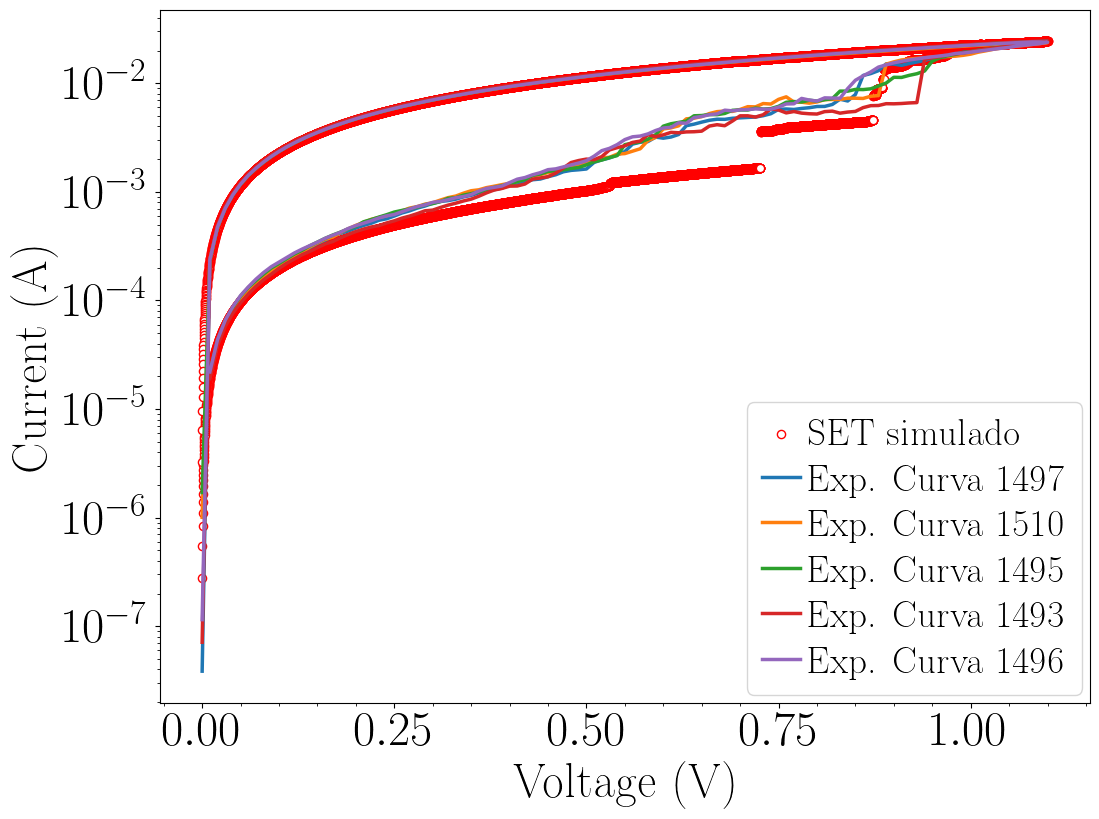

In [ ]:
# Uno los dataframes de la mejor curva
df_set_sim = pd.concat([df_pp_set, df_sp_set], ignore_index=True)

fig, ejes = plt.subplots(figsize=(12, 9))
setup_paper_plt(plt, latex=True, scaling=2.5)
config_ax_IV(ejes)

# Scatter de SET y RESET
ejes.scatter(
    df_set_sim["voltage"],
    abs(df_set_sim["current"]),
    color="red",
    s=35,
    marker=markers.MarkerStyle("o"),
    facecolors="white",
    label="SET simulado",
)
    
# Configuración de la figura
ejes.set_xlabel("Voltage (V)")
ejes.set_ylabel("Current (A)")
ejes.set_yscale("log")

for i in [1497, 1510, 1495, 1493, 1496]:
    df_pp_set_exp, df_sp_set_exp = leer_datos_exp(num_curva = i)
    df_set_exp = pd.concat([df_pp_set_exp, df_sp_set_exp], ignore_index=True)
    
    plot_all_IV_best_ajust(
        df_exp = df_set_exp,
        df_sim= df_set_sim,
        num_curva= i,)
        
        # Curvas experimentales
    ejes.plot(
        df_set_exp["voltage"],
        abs(df_set_exp["current"]),
        linewidth=2.5,
        label=f"Exp. Curva {num_curva}",
    )

    # Leyenda ajustada en la parte inferior izquierda
    ejes.legend(
        labelspacing=0.3,
        handletextpad=0.2,
        handlelength=1.0,
        borderaxespad=0.2,
        loc="lower right",
    )
    